In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
df = pd.read_csv("jiji_car_dataset.csv")
df.head(10)

,title,make,model,year,condition,transmission,price
0,Mercedes-Benz GLK-Class 350 4MATIC 2011 Black,Mercedes-Benz,GLK-Class 350,2011.0,local used,automatic,"₦ 9,500,000"
1,Dodge Charger SE AWD 2016 Gray,Dodge,Charger SE,2016.0,foreign used,automatic,"₦ 17,000,000"
2,Toyota Camry 2010 Black,Toyota,Camry,2010.0,local used,automatic,"₦ 9,492,187"
3,Toyota Venza AWD 2010 Brown,Toyota,Venza AWD,2010.0,local used,automatic,"₦ 8,700,000"
4,Honda Civic 2007 Black,Honda,Civic,2007.0,local used,automatic,"₦ 3,600,000"
5,Toyota Highlander XLE 4x2 V6 (3.5L 6cyl 8A) 20...,Toyota,Highlander XLE,2018.0,foreign used,automatic,"₦ 35,000,000"
6,Lexus GX 2013 Gold,Lexus,GX,2013.0,foreign used,automatic,"₦ 32,000,000"
7,Toyota Corolla 2010 Silver,Toyota,Corolla,2010.0,foreign used,automatic,"₦ 12,500,000"
8,Lexus ES 300 2004 Blue,Lexus,ES 300,2004.0,local used,automatic,"₦ 6,000,000"
9,Toyota Camry SE 4dr Sedan (2.5L 4cyl 6A) 2013 ...,Toyota,Camry SE,2013.0,foreign used,automatic,"₦ 13,800,000"


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1998 non-null   object 
 1   make          1994 non-null   object 
 2   model         1994 non-null   object 
 3   year          1994 non-null   float64
 4   condition     1998 non-null   object 
 5   transmission  1997 non-null   object 
 6   price         1998 non-null   object 
dtypes: float64(1), object(6)
memory usage: 109.4+ KB


In [61]:
df.isnull().sum()

title           0
make            4
model           4
year            4
condition       0
transmission    1
price           0
dtype: int64

In [62]:
df = df.dropna()

In [63]:
df.isnull().sum()

title           0
make            0
model           0
year            0
condition       0
transmission    0
price           0
dtype: int64

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1993 non-null   object 
 1   make          1993 non-null   object 
 2   model         1993 non-null   object 
 3   year          1993 non-null   float64
 4   condition     1993 non-null   object 
 5   transmission  1993 non-null   object 
 6   price         1993 non-null   object 
dtypes: float64(1), object(6)
memory usage: 124.6+ KB


In [65]:
df['price'] = (
    df['price']
    .astype(str)
    .replace('₦', "", regex=True)
    .replace(',', "", regex=True)    
    .astype(float).round(2)
)        
df['price'].head(10)

0     9500000.0
1    17000000.0
2     9492187.0
3     8700000.0
4     3600000.0
5    35000000.0
6    32000000.0
7    12500000.0
8     6000000.0
9    13800000.0
Name: price, dtype: float64

In [66]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# print(lower_bound)
# print(upper_bound)

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1814 entries, 0 to 1996
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1814 non-null   object 
 1   make          1814 non-null   object 
 2   model         1814 non-null   object 
 3   year          1814 non-null   float64
 4   condition     1814 non-null   object 
 5   transmission  1814 non-null   object 
 6   price         1814 non-null   float64
dtypes: float64(2), object(5)
memory usage: 113.4+ KB


In [67]:
categorical_cols = ['make', 'model', 'transmission', 'condition']

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df[categorical_cols].head(10)  

,make,model,transmission,condition
0,Mercedes-Benz,Glk-Class 350,Automatic,Local Used
1,Dodge,Charger Se,Automatic,Foreign Used
2,Toyota,Camry,Automatic,Local Used
3,Toyota,Venza Awd,Automatic,Local Used
4,Honda,Civic,Automatic,Local Used
5,Toyota,Highlander Xle,Automatic,Foreign Used
6,Lexus,Gx,Automatic,Foreign Used
7,Toyota,Corolla,Automatic,Foreign Used
8,Lexus,Es 300,Automatic,Local Used
9,Toyota,Camry Se,Automatic,Foreign Used


In [68]:
df['make'].unique()

array(['Mercedes-Benz', 'Dodge', 'Toyota', 'Honda', 'Lexus', 'Acura',
       'Geely', 'Nissan', 'Hyundai', 'Pontiac', 'Bmw', 'Infiniti',
       'Cadillac', 'Mazda', 'Ford', 'Peugeot', 'Land', 'Kia', 'Jeep',
       'Volkswagen', 'Porsche', 'Audi', 'Lincoln', 'Iveco', 'Mini',
       'Renault', 'Chevrolet', 'Gmc', 'Volvo', 'Mitsubishi', 'Gac',
       'Chrysler', 'Mg', 'Great', 'Opel'], dtype=object)

In [69]:
df['make'] = df['make'].replace({
    'Bmw': 'BMW',
    'Gmc': 'GMC',
    'Mg': 'MG',
    'Gac': 'GAC',
    'Land': 'Land Rover',
    'Great': 'Great Wall'
})
df['make'].unique()

array(['Mercedes-Benz', 'Dodge', 'Toyota', 'Honda', 'Lexus', 'Acura',
       'Geely', 'Nissan', 'Hyundai', 'Pontiac', 'BMW', 'Infiniti',
       'Cadillac', 'Mazda', 'Ford', 'Peugeot', 'Land Rover', 'Kia',
       'Jeep', 'Volkswagen', 'Porsche', 'Audi', 'Lincoln', 'Iveco',
       'Mini', 'Renault', 'Chevrolet', 'GMC', 'Volvo', 'Mitsubishi',
       'GAC', 'Chrysler', 'MG', 'Great Wall', 'Opel'], dtype=object)

In [70]:
df['year'].isnull().sum()

np.int64(0)

In [71]:
df['year'].unique()

array([2011., 2016., 2010., 2007., 2018., 2013., 2004., 2008., 2019.,
       2014., 2015., 2000., 2021., 2009., 2005., 2006., 2001., 2002.,
       2017., 2003., 2020., 2012., 2022., 1999., 2023., 2025., 1997.,
       1995., 1993., 1996., 2024.])

In [72]:
df['year'].astype(int)

0       2011
1       2016
2       2010
3       2010
4       2007
        ... 
1992    2006
1993    2013
1994    2004
1995    2010
1996    2008
Name: year, Length: 1814, dtype: int64

<Axes: xlabel='make'>

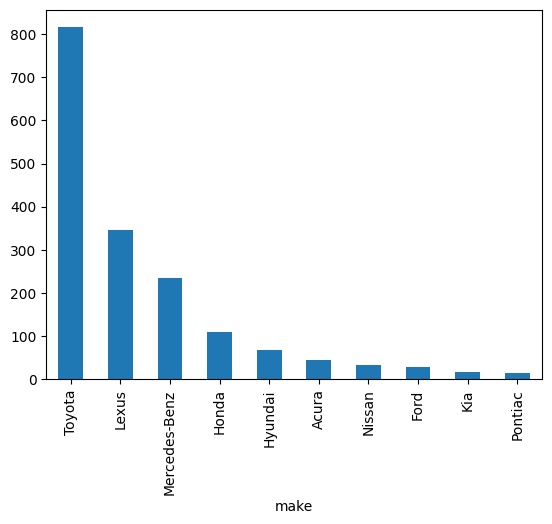

In [73]:
make_counts = df['make'].value_counts()
make_counts.head(10).plot(kind='bar')

In [74]:
model_counts = df.groupby('make')['model'].value_counts()
top_models_per_brand = model_counts.groupby(level=0).head(1)
top_models_df = top_models_per_brand.reset_index(name='count')
top_models_df

,make,model,count
0,Acura,Mdx,10
1,Audi,A4 1,2
2,BMW,7 Series,2
3,Cadillac,Escalade,2
4,Chevrolet,Spark,1
5,Chrysler,Pacifica,1
6,Dodge,Charger Se,3
7,Ford,Edge,7
8,GAC,Gs4,1
9,GMC,Acadia,1


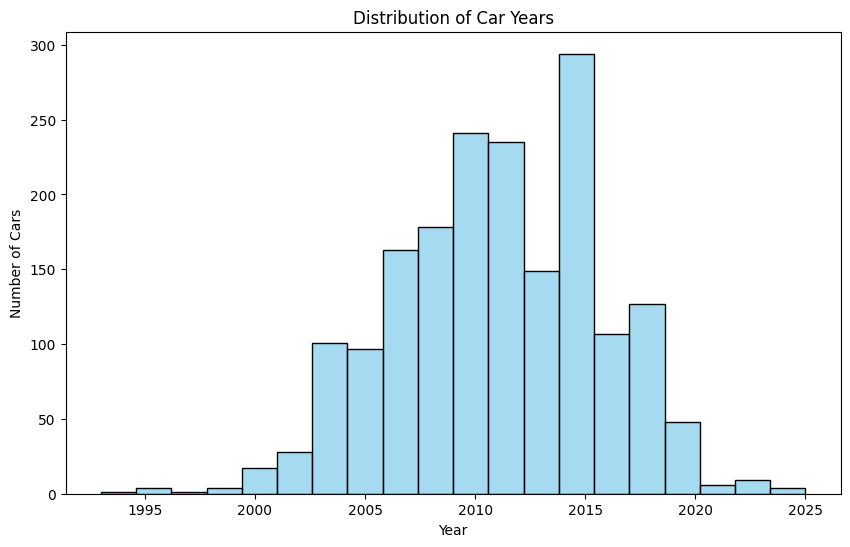

In [76]:
plt.figure(figsize=(10,6))
sns.histplot(df['year'], bins=20, kde=False, color='skyblue')
plt.title('Distribution of Car Years')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.show()

In [80]:
avg_price_make_model = df.groupby(['make', 'model'])['price'].mean().sort_values(ascending=False)
avg_price_df = avg_price_make_model.reset_index(name='avg_price')
avg_price_df['avg_price'] = avg_price_df['avg_price'].apply(lambda x: f"₦{x:,.0f}")
avg_price_df.head(10)

,make,model,avg_price
0,Toyota,Highlander Platinum,"₦48,500,000"
1,Mercedes-Benz,Gle-Class Amg,"₦45,500,000"
2,Toyota,Highlander L,"₦45,000,000"
3,Mercedes-Benz,S-Class,"₦45,000,000"
4,BMW,X2 Xdrive28I,"₦43,000,000"
5,Mercedes-Benz,Gls-Class Gls450,"₦41,750,000"
6,Mercedes-Benz,Gle-Class,"₦40,925,714"
7,Mercedes-Benz,E300,"₦40,000,000"
8,Lexus,Gx 460,"₦38,169,231"
9,Toyota,Tacoma Limited,"₦37,740,000"


In [90]:
most_expe_avg = avg_price_df['make'].mode()
print(f"{list(most_expe_avg)} is the most expensive on average")

['Toyota'] is the most expensive on average


In [95]:
condition_price_mean = df.groupby('condition')['price'].mean()
condition_price_mean.apply(lambda x: f"₦{x:,.0f}")

condition
Foreign Used    ₦19,014,616
Local Used       ₦9,087,213
Name: price, dtype: object

C:\Users\HP 840 G3\AppData\Local\Temp\ipykernel_2004\1266908453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='price', data=df, palette='Set2')


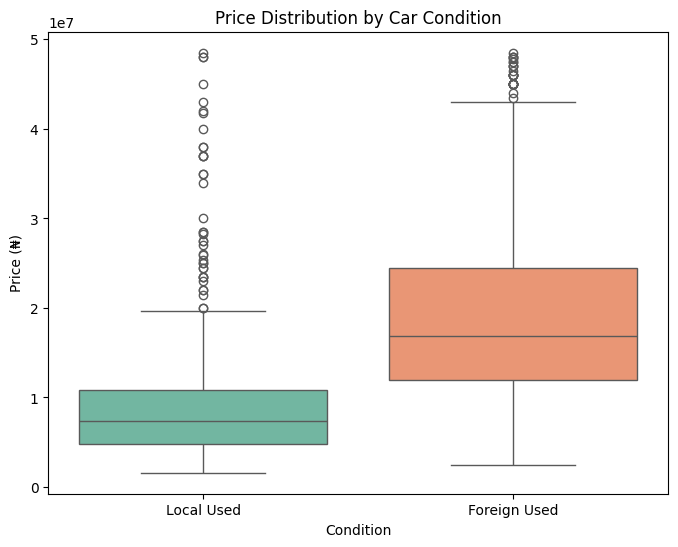

In [96]:
plt.figure(figsize=(8,6))
sns.boxplot(x='condition', y='price', data=df, palette='Set2')
plt.title('Price Distribution by Car Condition')
plt.ylabel('Price (₦)')
plt.xlabel('Condition')
plt.show()

In [98]:
transmission_price_mean = df.groupby('transmission')['price'].mean()
transmission_price_mean.apply(lambda x: f"₦{x:,.0f}")

transmission
Automatic    ₦15,674,116
Manual        ₦5,481,667
Name: price, dtype: object

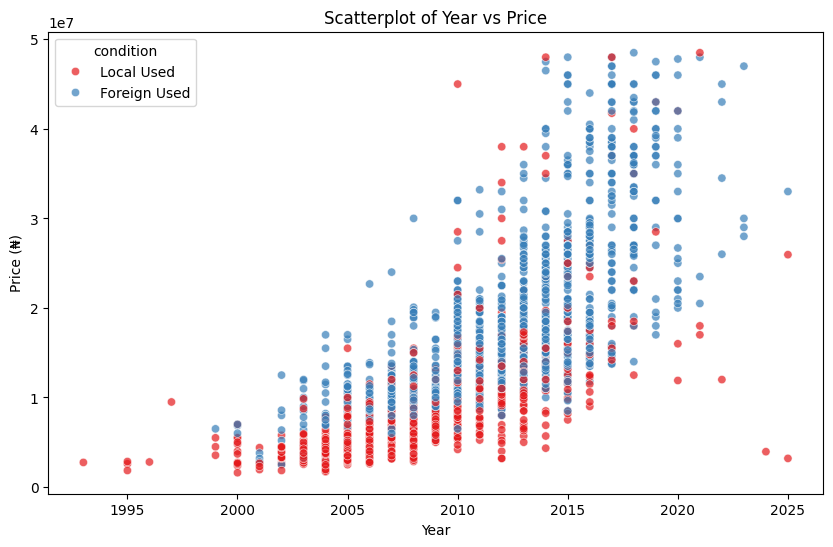

In [101]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='year', y='price', data=df, hue='condition', palette='Set1', alpha=0.7)
plt.title('Scatterplot of Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price (₦)')
plt.show()

In [102]:
correlation = df['year'].corr(df['price'])
print(f"Correlation between year and price: {correlation:.2f}")

Correlation between year and price: 0.73


In [103]:
df.to_csv( "jiji_car_dataset.csv", index=False)